# Fase 4 — Modelado
## Proyecto: Accesibilidad de Vivienda en Colombia · CRISP-DM 2026-I
**Responsable:** Steve · **Apoyo:** Kukis
**Dataset:** `vivienda_colombia_limpio.csv` (282.660 × 26, 2020–2024)


## Sección 1: Setup y Carga del Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json
import os
os.chdir('C:\\Users\\AlexP\\OneDrive\\Escritorio\\Accesibilidad_de_Vivienda_en_Colombia')
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score

os.makedirs("models", exist_ok=True)
print("✅ Imports completados, carpeta models/ lista")


✅ Imports completados, carpeta models/ lista


In [2]:
# Cargar dataset
df = pd.read_csv("data/processed/vivienda_colombia_limpio.csv", encoding="utf-8-sig")
print(f"Shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


Shape: (282660, 26)
Columnas: ['price', 'area', 'rooms', 'bathrooms', 'property_type', 'city', 'lat', 'lon', 'created_on', 'estrato', 'fuente', 'year', 'salario_mensual', 'ipc_var_anual', 'ipc_base2018', 'tasa_hipotecaria_anual', 'tasa_desempleo', 'ipvu_variacion_anual', 'ipvn_variacion_anual', 'salario_anual', 'IAH', 'precio_real', 'precio_m2', 'cuota_mensual', 'ratio_cuota_salario', 'nivel_accesibilidad']


Memoria: 127.5 MB


In [3]:
# Verificación de calidad
print("Nulos por columna crítica:")
for c in ['price','area','rooms','bathrooms','property_type','city','lat','lon','estrato','year']:
    print(f"  {c}: {df[c].isna().sum()}")
print(f"\nAños: {df['year'].value_counts().sort_index().to_dict()}")
print(f"\nCiudades ({df['city'].nunique()}): {sorted(df['city'].unique())}")
print(f"\nFuentes: {df['fuente'].value_counts().to_dict()}")


Nulos por columna crítica:
  price: 0
  area: 0
  rooms: 0
  bathrooms: 0
  property_type: 0
  city: 0
  lat: 0
  lon: 0
  estrato: 0
  year: 0

Años: {2020: 60399, 2021: 75535, 2022: 69993, 2023: 8014, 2024: 68719}

Ciudades (12): ['Armenia', 'Barranquilla', 'Bogotá', 'Bucaramanga', 'Cali', 'Cartagena', 'Cúcuta', 'Ibagué', 'Manizales', 'Medellín', 'Pereira', 'Villavicencio']

Fuentes: {'A1_Properati': 135934, 'A2_FincaRaiz_Kaggle': 72393, 'A3_Kaggle': 63950, 'A5_Medellin_Kaggle': 5557, 'A4_Bogota_Kaggle': 4312, 'A6_Bogota2023_Kaggle': 514}


In [4]:
# Verificar encoding de ciudades (tildes)
print("Verificación de tildes en nombres de ciudad:")
for c in sorted(df['city'].unique()):
    print(f"  {c} -> bytes: {c.encode('utf-8')}")


Verificación de tildes en nombres de ciudad:
  Armenia -> bytes: b'Armenia'
  Barranquilla -> bytes: b'Barranquilla'
  Bogotá -> bytes: b'Bogot\xc3\xa1'
  Bucaramanga -> bytes: b'Bucaramanga'
  Cali -> bytes: b'Cali'
  Cartagena -> bytes: b'Cartagena'
  Cúcuta -> bytes: b'C\xc3\xbacuta'
  Ibagué -> bytes: b'Ibagu\xc3\xa9'
  Manizales -> bytes: b'Manizales'
  Medellín -> bytes: b'Medell\xc3\xadn'
  Pereira -> bytes: b'Pereira'
  Villavicencio -> bytes: b'Villavicencio'


## Sección 2: Preparación de Features

In [5]:
# Definir variables
# NOTA: year se trata como categórica (decisión del proyecto)
FEATURES_NUM = ['area', 'rooms', 'bathrooms', 'estrato',
                'ipc_var_anual', 'tasa_hipotecaria_anual',
                'tasa_desempleo', 'ipvu_variacion_anual']
FEATURES_CAT = ['city', 'property_type', 'year']
TARGET = 'price'

X = df[FEATURES_NUM + FEATURES_CAT].copy()
y = df[TARGET].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features numéricas ({len(FEATURES_NUM)}): {FEATURES_NUM}")
print(f"Features categóricas ({len(FEATURES_CAT)}): {FEATURES_CAT}")


X shape: (282660, 11)
y shape: (282660,)
Features numéricas (8): ['area', 'rooms', 'bathrooms', 'estrato', 'ipc_var_anual', 'tasa_hipotecaria_anual', 'tasa_desempleo', 'ipvu_variacion_anual']
Features categóricas (3): ['city', 'property_type', 'year']


In [6]:
# VIF - Multicolinealidad (solo numéricas)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

X_num = X[FEATURES_NUM].dropna()
X_vif = add_constant(X_num)
vif_data = pd.DataFrame()
vif_data["feature"] = FEATURES_NUM
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(FEATURES_NUM))]
print("VIF por variable numérica:")
print(vif_data.to_string(index=False))
print("\n(Ridge maneja colinealidad — no se eliminan variables)")


VIF por variable numérica:
               feature       VIF
                  area  1.778238
                 rooms  1.601286
             bathrooms  1.697720
               estrato  1.252765
         ipc_var_anual  1.842353
tasa_hipotecaria_anual 38.964799
        tasa_desempleo 85.458012
  ipvu_variacion_anual 18.453881

(Ridge maneja colinealidad — no se eliminan variables)


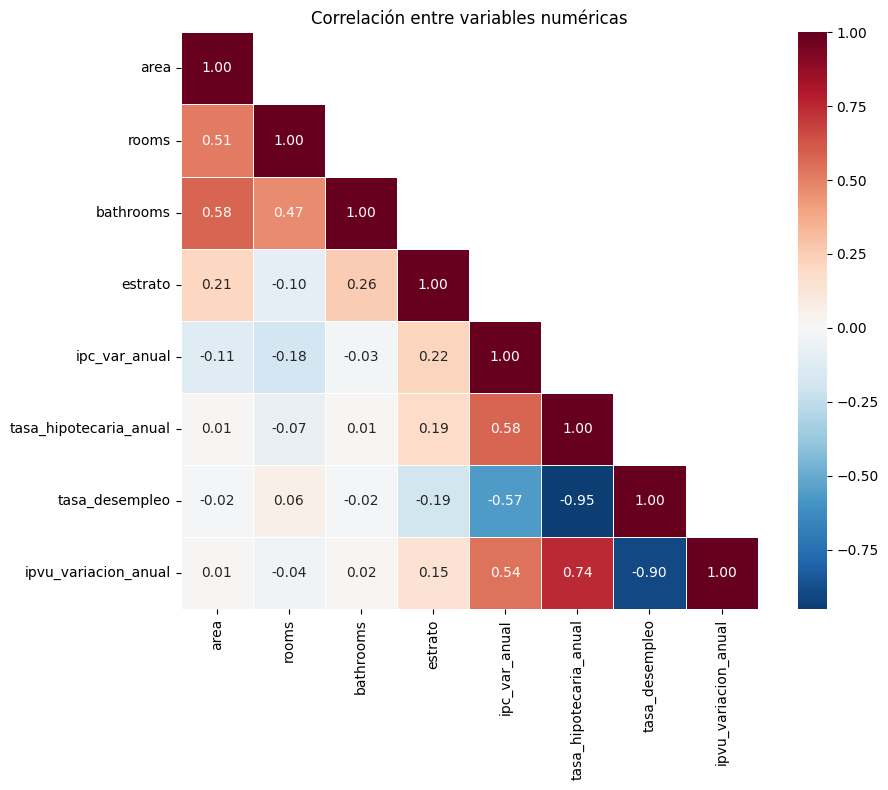

In [7]:
# Heatmap de correlación entre numéricas
plt.figure(figsize=(10, 8))
corr = X_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.savefig("models/heatmap_correlacion.png", dpi=100, bbox_inches='tight')
plt.show()


In [8]:
# División train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train: {X_train.shape[0]:,} registros")
print(f"Test:  {X_test.shape[0]:,} registros")
print(f"\nDistribución de city en train:")
print(X_train['city'].value_counts(normalize=True).head(5))
print(f"\nDistribución de city en test:")
print(X_test['city'].value_counts(normalize=True).head(5))


Train: 226,128 registros
Test:  56,532 registros

Distribución de city en train:
city
Bogotá          0.531690
Medellín        0.130554
Cali            0.118760
Barranquilla    0.060873
Manizales       0.042467
Name: proportion, dtype: float64

Distribución de city en test:
city
Bogotá          0.532831
Medellín        0.126247
Cali            0.120817
Barranquilla    0.061841
Manizales       0.042100
Name: proportion, dtype: float64


In [9]:
# Pipeline de preprocesamiento
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT)
])

preprocessor.fit(X_train)  # sin fuga de info
print(f"Features tras transformación: {preprocessor.get_feature_names_out().shape[0]}")
print("✅ Preprocessor listo")


Features tras transformación: 27
✅ Preprocessor listo


## Sección 3: Modelo Baseline — Ridge Regression

In [10]:
# Ridge baseline
pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])
pipeline_ridge.fit(X_train, y_train)
y_pred_ridge = pipeline_ridge.predict(X_test)

# Métricas
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
rmse_rel_ridge = rmse_ridge / y_test.median() * 100

print(f"Ridge Regression — Métricas en test:")
print(f"  R²:            {r2_ridge:.4f}")
print(f"  MAE:           ${mae_ridge:,.0f}")
print(f"  RMSE:          ${rmse_ridge:,.0f}")
print(f"  RMSE relativo: {rmse_rel_ridge:.2f}%")


Ridge Regression — Métricas en test:
  R²:            0.5382
  MAE:           $204,253,848
  RMSE:          $320,466,412
  RMSE relativo: 76.30%


In [11]:
# Validación cruzada 5-fold
cv_scores_ridge = cross_val_score(pipeline_ridge, X_train, y_train, cv=5, scoring='r2')
print(f"CV R² — media: {cv_scores_ridge.mean():.4f} ± {cv_scores_ridge.std():.4f}")
print(f"CV R² — scores individuales: {cv_scores_ridge}")


CV R² — media: 0.5305 ± 0.0037
CV R² — scores individuales: [0.52888847 0.53447217 0.52977848 0.53479171 0.52477779]


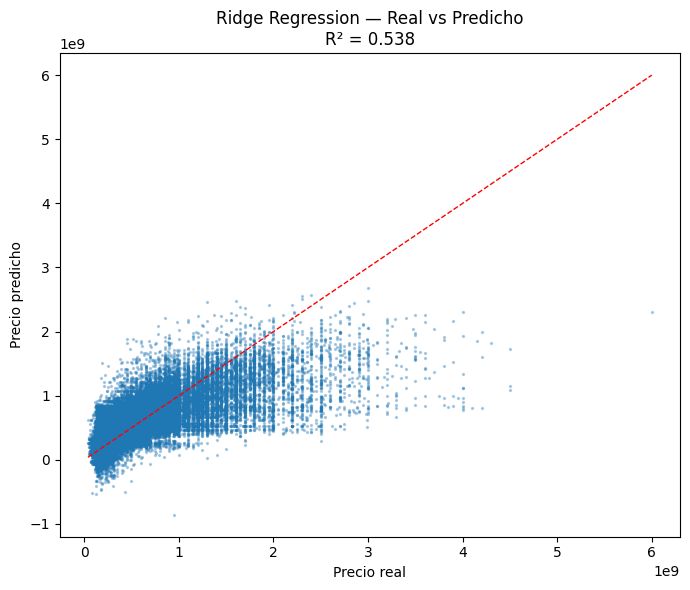

In [12]:
# Scatter: valores reales vs predichos
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.3, s=2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title(f'Ridge Regression — Real vs Predicho\nR² = {r2_ridge:.3f}')
plt.tight_layout()
plt.savefig("models/scatter_ridge.png", dpi=100, bbox_inches='tight')
plt.show()


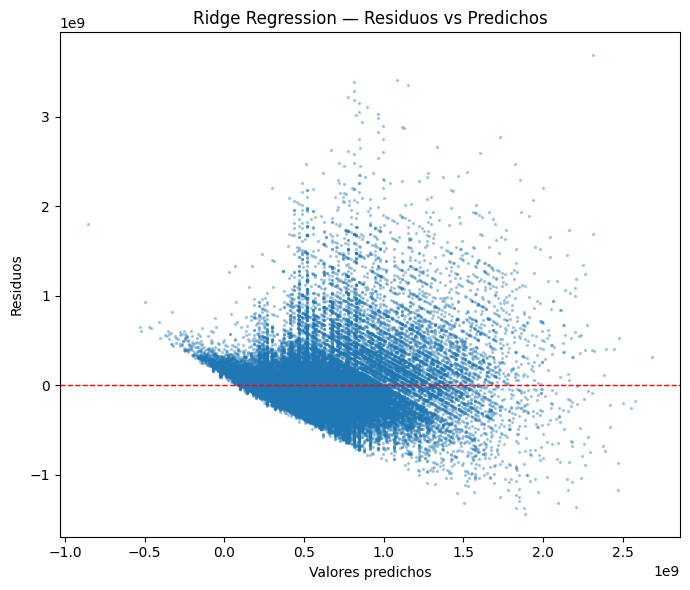

In [13]:
# Residuos
residuos_ridge = y_test - y_pred_ridge
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_ridge, residuos_ridge, alpha=0.3, s=2)
plt.axhline(y=0, color='r', linestyle='--', lw=1)
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Ridge Regression — Residuos vs Predichos')
plt.tight_layout()
plt.savefig("models/residuos_ridge.png", dpi=100, bbox_inches='tight')
plt.show()


## Sección 4: Modelo Principal — Random Forest Regressor

In [14]:
# Random Forest inicial
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_rel_rf = rmse_rf / y_test.median() * 100

print(f"Random Forest (100 trees) — Métricas en test:")
print(f"  R²:            {r2_rf:.4f}")
print(f"  MAE:           ${mae_rf:,.0f}")
print(f"  RMSE:          ${rmse_rf:,.0f}")
print(f"  RMSE relativo: {rmse_rel_rf:.2f}%")


Random Forest (100 trees) — Métricas en test:
  R²:            0.6261
  MAE:           $169,353,591
  RMSE:          $288,343,135
  RMSE relativo: 68.65%


In [15]:
# Validación cruzada RF
cv_scores_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=3, scoring='r2')
print(f"CV R² (3-fold) — media: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
print(f"CV R² — scores: {cv_scores_rf}")


CV R² (3-fold) — media: 0.6231 ± 0.0006
CV R² — scores: [0.62223944 0.62335921 0.62356661]


In [16]:
# Comparación Ridge vs RF
print("\n" + "="*60)
print("COMPARACIÓN: Ridge vs Random Forest (inicial)")
print("="*60)
print(f"{'Métrica':<25} {'Ridge':>12} {'RF':>12}")
print("-"*49)
print(f"{'R²':<25} {r2_ridge:>12.4f} {r2_rf:>12.4f}")
print(f"{'MAE':<25} {mae_ridge:>12,.0f} {mae_rf:>12,.0f}")
print(f"{'RMSE':<25} {rmse_ridge:>12,.0f} {rmse_rf:>12,.0f}")
print(f"{'RMSE rel %':<25} {rmse_rel_ridge:>12.2f} {rmse_rel_rf:>12.2f}")

diff = (r2_rf - r2_ridge) * 100
print(f"\nRF supera a Ridge en R² por {diff:.2f} pp")
if diff > 10:
    print("✅ Diferencia > 10 pp — RF seleccionado como modelo principal")
else:
    print("⚠️ Diferencia < 10 pp — Ridge podría ser suficiente")



COMPARACIÓN: Ridge vs Random Forest (inicial)
Métrica                          Ridge           RF
-------------------------------------------------
R²                              0.5382       0.6261
MAE                        204,253,848  169,353,591
RMSE                       320,466,412  288,343,135
RMSE rel %                       76.30        68.65

RF supera a Ridge en R² por 8.79 pp
⚠️ Diferencia < 10 pp — Ridge podría ser suficiente


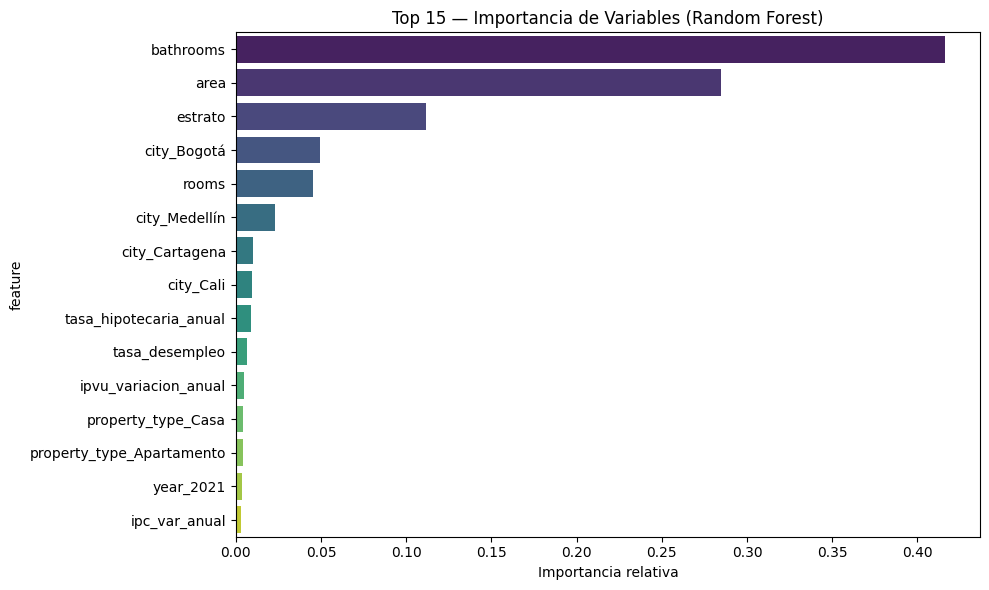

In [17]:
# Feature importance
encoder = preprocessor.named_transformers_['cat']
cat_features = encoder.get_feature_names_out(FEATURES_CAT)
all_feature_names = list(FEATURES_NUM) + list(cat_features)

importances = pipeline_rf.named_steps['regressor'].feature_importances_
feat_imp = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, y='feature', x='importance', palette='viridis')
plt.title('Top 15 — Importancia de Variables (Random Forest)')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig("models/feature_importance.png", dpi=100, bbox_inches='tight')
plt.show()


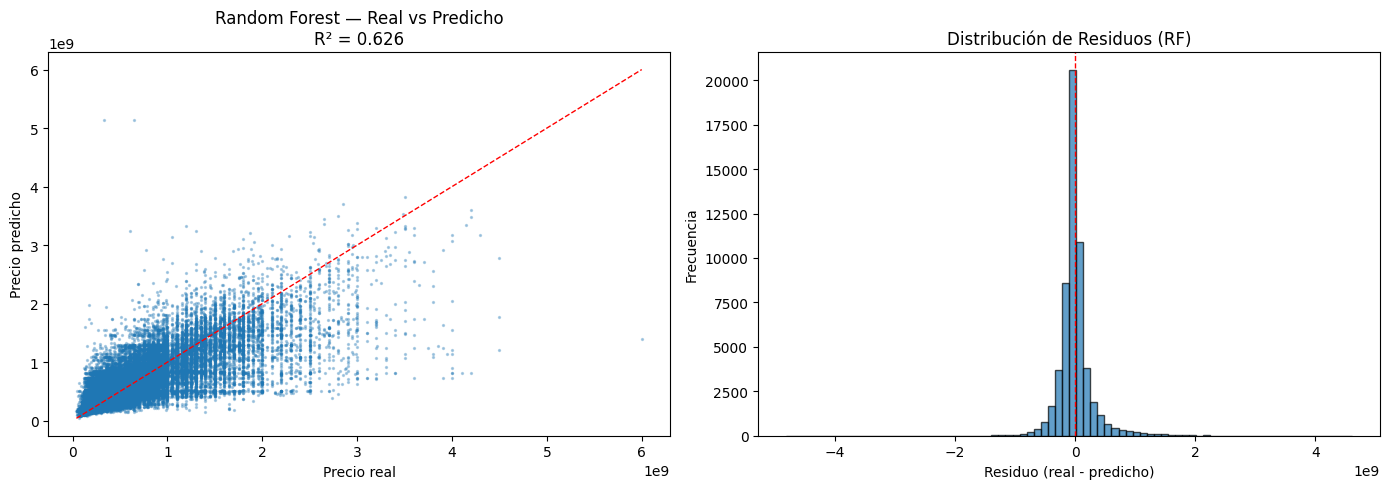

In [18]:
# Residuos RF
residuos_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter real vs predicho
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, s=2)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
axes[0].set_xlabel('Precio real')
axes[0].set_ylabel('Precio predicho')
axes[0].set_title(f'Random Forest — Real vs Predicho\nR² = {r2_rf:.3f}')

# Histograma de residuos
axes[1].hist(residuos_rf, bins=80, alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', lw=1)
axes[1].set_xlabel('Residuo (real - predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos (RF)')
plt.tight_layout()
plt.savefig("models/diagnostico_rf.png", dpi=100, bbox_inches='tight')
plt.show()


Error absoluto medio por ciudad:
                error_medio  error_abs_medio  count
city                                               
Cartagena     -1.202923e+07     3.460144e+08    830
Medellín       1.435386e+06     1.858922e+08   7137
Bogotá         2.645384e+06     1.807978e+08  30122
Cali           3.147778e+06     1.558522e+08   6830
Barranquilla   1.958327e+06     1.495223e+08   3496
Pereira       -1.176369e+06     1.383798e+08   1593
Cúcuta         5.092020e+06     1.327897e+08   1076
Bucaramanga   -2.955730e+06     1.136832e+08   1492
Ibagué        -2.630350e+06     1.107700e+08    780
Manizales      2.695592e+06     1.001389e+08   2380
Villavicencio -8.760992e+06     8.829774e+07    500
Armenia       -1.232878e+07     8.440886e+07    296


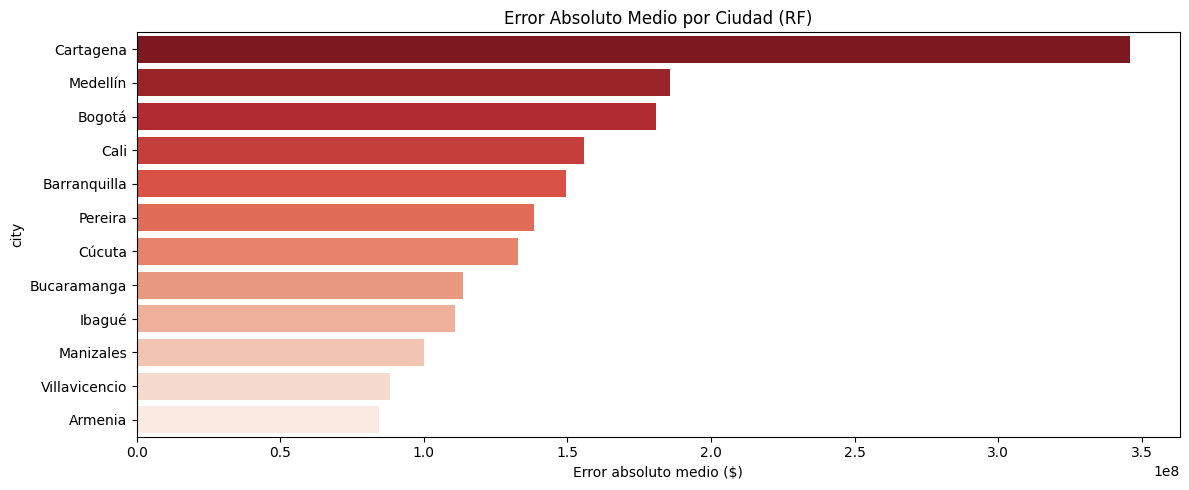

In [19]:
# Residuos por ciudad
X_test_res = X_test.copy()
X_test_res['residuo'] = residuos_rf
X_test_res['residuo_abs'] = np.abs(residuos_rf)

city_error = X_test_res.groupby('city').agg(
    error_medio=('residuo', 'mean'),
    error_abs_medio=('residuo_abs', 'mean'),
    count=('residuo', 'count')
).sort_values('error_abs_medio', ascending=False)

print("Error absoluto medio por ciudad:")
print(city_error.to_string())

plt.figure(figsize=(12, 5))
sns.barplot(data=city_error.reset_index(), y='city', x='error_abs_medio', palette='Reds_r')
plt.title('Error Absoluto Medio por Ciudad (RF)')
plt.xlabel('Error absoluto medio ($)')
plt.tight_layout()
plt.savefig("models/error_por_ciudad.png", dpi=100, bbox_inches='tight')
plt.show()


In [20]:
# GridSearchCV — optimización de hiperparámetros
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5]
}

print(f"GridSearch: {len(param_grid['regressor__n_estimators']) * len(param_grid['regressor__max_depth']) * len(param_grid['regressor__min_samples_split'])} combinaciones × 5 folds")
print("Esto puede tomar varios minutos...")

grid_search = GridSearchCV(
    pipeline_rf, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor R² (CV): {grid_search.best_score_:.4f}")


GridSearch: 12 combinaciones × 5 folds
Esto puede tomar varios minutos...
Fitting 5 folds for each of 12 candidates, totalling 60 fits



Mejores parámetros: {'regressor__max_depth': 20, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Mejor R² (CV): 0.6320


In [21]:
# Evaluar modelo optimizado
pipeline_rf_opt = grid_search.best_estimator_
y_pred_rf_opt = pipeline_rf_opt.predict(X_test)

r2_opt = r2_score(y_test, y_pred_rf_opt)
mae_opt = mean_absolute_error(y_test, y_pred_rf_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_rf_opt))
rmse_rel_opt = rmse_opt / y_test.median() * 100

print(f"Random Forest OPTIMIZADO — Métricas en test:")
print(f"  R²:            {r2_opt:.4f}")
print(f"  MAE:           ${mae_opt:,.0f}")
print(f"  RMSE:          ${rmse_opt:,.0f}")
print(f"  RMSE relativo: {rmse_rel_opt:.2f}%")
print(f"  Mejora vs RF base: R² +{(r2_opt - r2_rf)*100:.2f} pp")


Random Forest OPTIMIZADO — Métricas en test:
  R²:            0.6348
  MAE:           $168,048,700
  RMSE:          $284,996,129
  RMSE relativo: 67.86%
  Mejora vs RF base: R² +0.86 pp


## Sección 5: Exportación del Modelo de Regresión

In [22]:
import joblib

# Guardar modelo optimizado
joblib.dump(pipeline_rf_opt, 'models/modelo_random_forest.pkl')
print("✅ models/modelo_random_forest.pkl guardado")

# Guardar orden de features
with open('models/features_order.json', 'w') as f:
    json.dump(FEATURES_NUM + FEATURES_CAT, f)
print("✅ models/features_order.json guardado")

# Verificar carga + predicción
model_loaded = joblib.load('models/modelo_random_forest.pkl')
sample = X_test.iloc[[0]]
pred = model_loaded.predict(sample)
print(f"\nPredicción de prueba: ${pred[0]:,.0f}")
print(f"Valor real: ${y_test.iloc[0]:,.0f}")
print("✅ Modelo carga y predice correctamente")


✅ models/modelo_random_forest.pkl guardado
✅ models/features_order.json guardado



Predicción de prueba: $283,487,328
Valor real: $250,000,000
✅ Modelo carga y predice correctamente


## Sección 6: Preparación de Features para Clustering

In [23]:
# Dataset de clustering: medianas por (city, year)
cluster_vars = ['IAH', 'precio_m2', 'ratio_cuota_salario', 'tasa_desempleo']

df_cluster = df.groupby(['city', 'year'])[cluster_vars].median().reset_index()
print(f"Filas para clustering: {len(df_cluster)} (esperadas 60, reales 51)")
print(f"Combinaciones faltantes: {60 - len(df_cluster)}")
print(f"\nAños por ciudad:")
print(df_cluster.groupby('city').size().to_string())


Filas para clustering: 51 (esperadas 60, reales 51)
Combinaciones faltantes: 9

Años por ciudad:
city
Armenia          2
Barranquilla     2
Bogotá           5
Bucaramanga      5
Cali             5
Cartagena        2
Cúcuta           5
Ibagué           5
Manizales        5
Medellín         5
Pereira          5
Villavicencio    5


In [24]:
# Escalar variables de clustering
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df_cluster[cluster_vars])
print(f"Variables escaladas: {X_cluster.shape}")
print(f"Medias tras escala: {X_cluster.mean(axis=0).round(4)}")
print(f"Desviaciones tras escala: {X_cluster.std(axis=0).round(4)}")


Variables escaladas: (51, 4)
Medias tras escala: [-0.  0. -0.  0.]
Desviaciones tras escala: [1. 1. 1. 1.]


## Sección 7: KMeans — Segmentación de Mercados

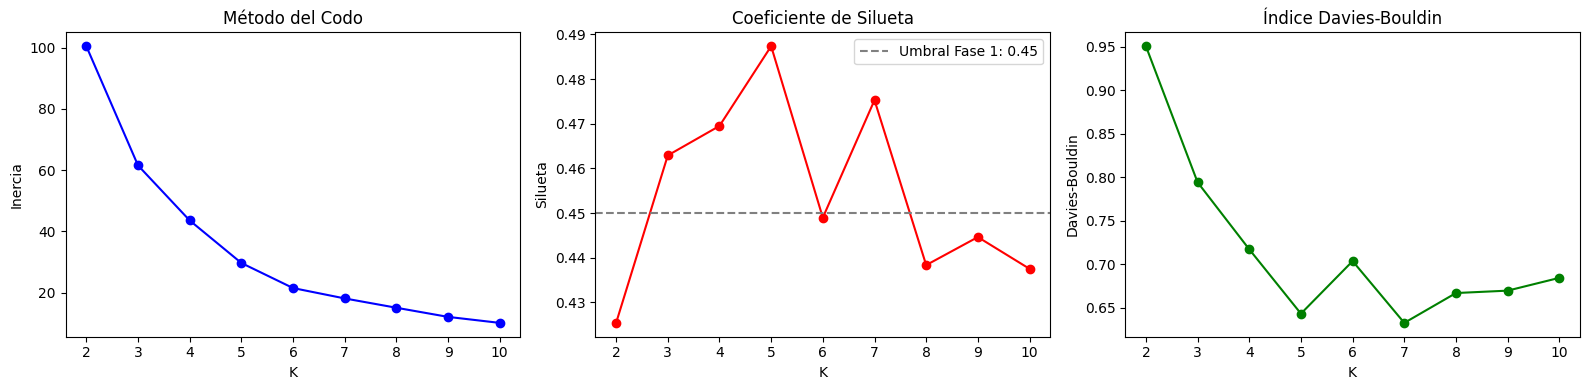

Siluetas por K:
  K=2: silueta=0.4254
  K=3: silueta=0.4629
  K=4: silueta=0.4695
  K=5: silueta=0.4874
  K=6: silueta=0.4490
  K=7: silueta=0.4753
  K=8: silueta=0.4383
  K=9: silueta=0.4446
  K=10: silueta=0.4375


In [25]:
# Determinación de K óptimo
K_range = range(2, 11)
inercia = []
siluetas = []
davies_bouldin = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_cluster)
    inercia.append(km.inertia_)
    siluetas.append(silhouette_score(X_cluster, labels))
    davies_bouldin.append(__import__('sklearn.metrics', fromlist=['davies_bouldin_score']).davies_bouldin_score(X_cluster, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(K_range, inercia, 'bo-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[1].plot(K_range, siluetas, 'ro-')
axes[1].axhline(y=0.45, color='gray', linestyle='--', label='Umbral Fase 1: 0.45')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silueta')
axes[1].set_title('Coeficiente de Silueta')
axes[1].legend()
axes[2].plot(K_range, davies_bouldin, 'go-')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Davies-Bouldin')
axes[2].set_title('Índice Davies-Bouldin')
plt.tight_layout()
plt.savefig("models/seleccion_k.png", dpi=100, bbox_inches='tight')
plt.show()

print(f"Siluetas por K:")
for k, s in zip(K_range, siluetas):
    print(f"  K={k}: silueta={s:.4f}")


In [26]:
# Seleccionar K
# Prioridad negocio: ≥ 3 clusters diferenciables
# Elegir el K con mejor silueta que cumpla K >= 3
valid_k = [(k, s) for k, s in zip(K_range, siluetas) if k >= 3]
K_optimo = max(valid_k, key=lambda x: x[1])[0]
print(f"K óptimo seleccionado: {K_optimo} (silueta={siluetas[K_optimo-2]:.4f})")


K óptimo seleccionado: 5 (silueta=0.4874)


In [27]:
# Entrenar KMeans final
kmeans = KMeans(n_clusters=K_optimo, init='k-means++', n_init=20, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X_cluster)

silueta_final = silhouette_score(X_cluster, df_cluster['cluster'])
print(f"Coeficiente de silueta final: {silueta_final:.4f}")
print(f"Umbral Fase 1 (≥ 0.45): {'✅ CUMPLE' if silueta_final >= 0.45 else '❌ NO CUMPLE'}")


Coeficiente de silueta final: 0.4874
Umbral Fase 1 (≥ 0.45): ✅ CUMPLE


In [28]:
# Perfiles de cluster
perfiles = df_cluster.groupby('cluster')[cluster_vars].mean().round(2)
perfiles['count'] = df_cluster.groupby('cluster').size()
print("Perfiles de clusters (media de variables):")
print(perfiles.to_string())


Perfiles de clusters (media de variables):
           IAH   precio_m2  ratio_cuota_salario  tasa_desempleo  count
cluster                                                               
0        29.23  4597674.42                 2.52           15.70      6
1        16.24  2144328.17                 1.40           15.70     18
2        18.66  3376073.33                 2.37           10.62     12
3        25.35  4904361.17                 3.29           10.45      6
4        12.93  2524136.49                 1.59           10.73      9


In [29]:
# Nombres cualitativos
cluster_names = {}
for k in range(K_optimo):
    row = perfiles.loc[k]
    if row['IAH'] > 30:
        name = "Crítico - Alto costo"
    elif row['IAH'] > 20:
        name = "Elevado"
    elif row['IAH'] > 10:
        name = "Moderado"
    else:
        name = "Accesible"
    cluster_names[k] = f"{name} (IAH {row['IAH']:.1f})"

df_cluster['cluster_name'] = df_cluster['cluster'].map(cluster_names)
print("Nombres asignados:")
for k, v in cluster_names.items():
    print(f"  Cluster {k}: {v}")


Nombres asignados:
  Cluster 0: Elevado (IAH 29.2)
  Cluster 1: Moderado (IAH 16.2)
  Cluster 2: Moderado (IAH 18.7)
  Cluster 3: Elevado (IAH 25.4)
  Cluster 4: Moderado (IAH 12.9)


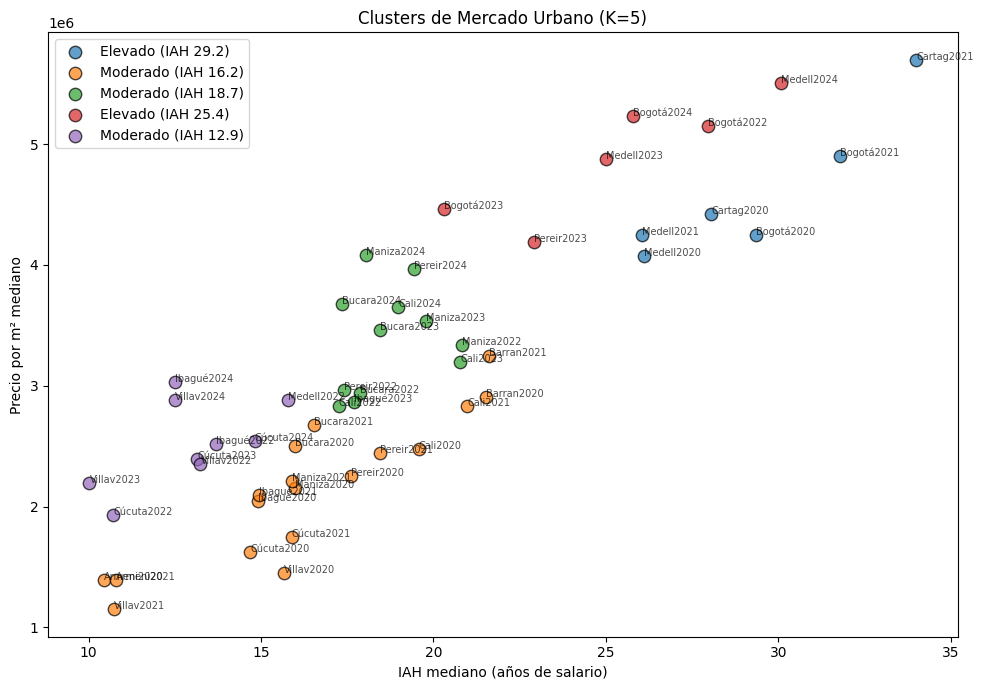

In [30]:
# Scatter IAH vs precio_m2 por cluster
plt.figure(figsize=(10, 7))
for k in range(K_optimo):
    subset = df_cluster[df_cluster['cluster'] == k]
    plt.scatter(subset['IAH'], subset['precio_m2'],
                label=cluster_names[k], s=80, alpha=0.7, edgecolors='k')
    for _, row in subset.iterrows():
        plt.annotate(f"{row['city'][:6]}{row['year']}",
                     (row['IAH'], row['precio_m2']),
                     fontsize=7, alpha=0.7)

plt.xlabel('IAH mediano (años de salario)')
plt.ylabel('Precio por m² mediano')
plt.title(f'Clusters de Mercado Urbano (K={K_optimo})')
plt.legend()
plt.tight_layout()
plt.savefig("models/clusters_scatter.png", dpi=100, bbox_inches='tight')
plt.show()


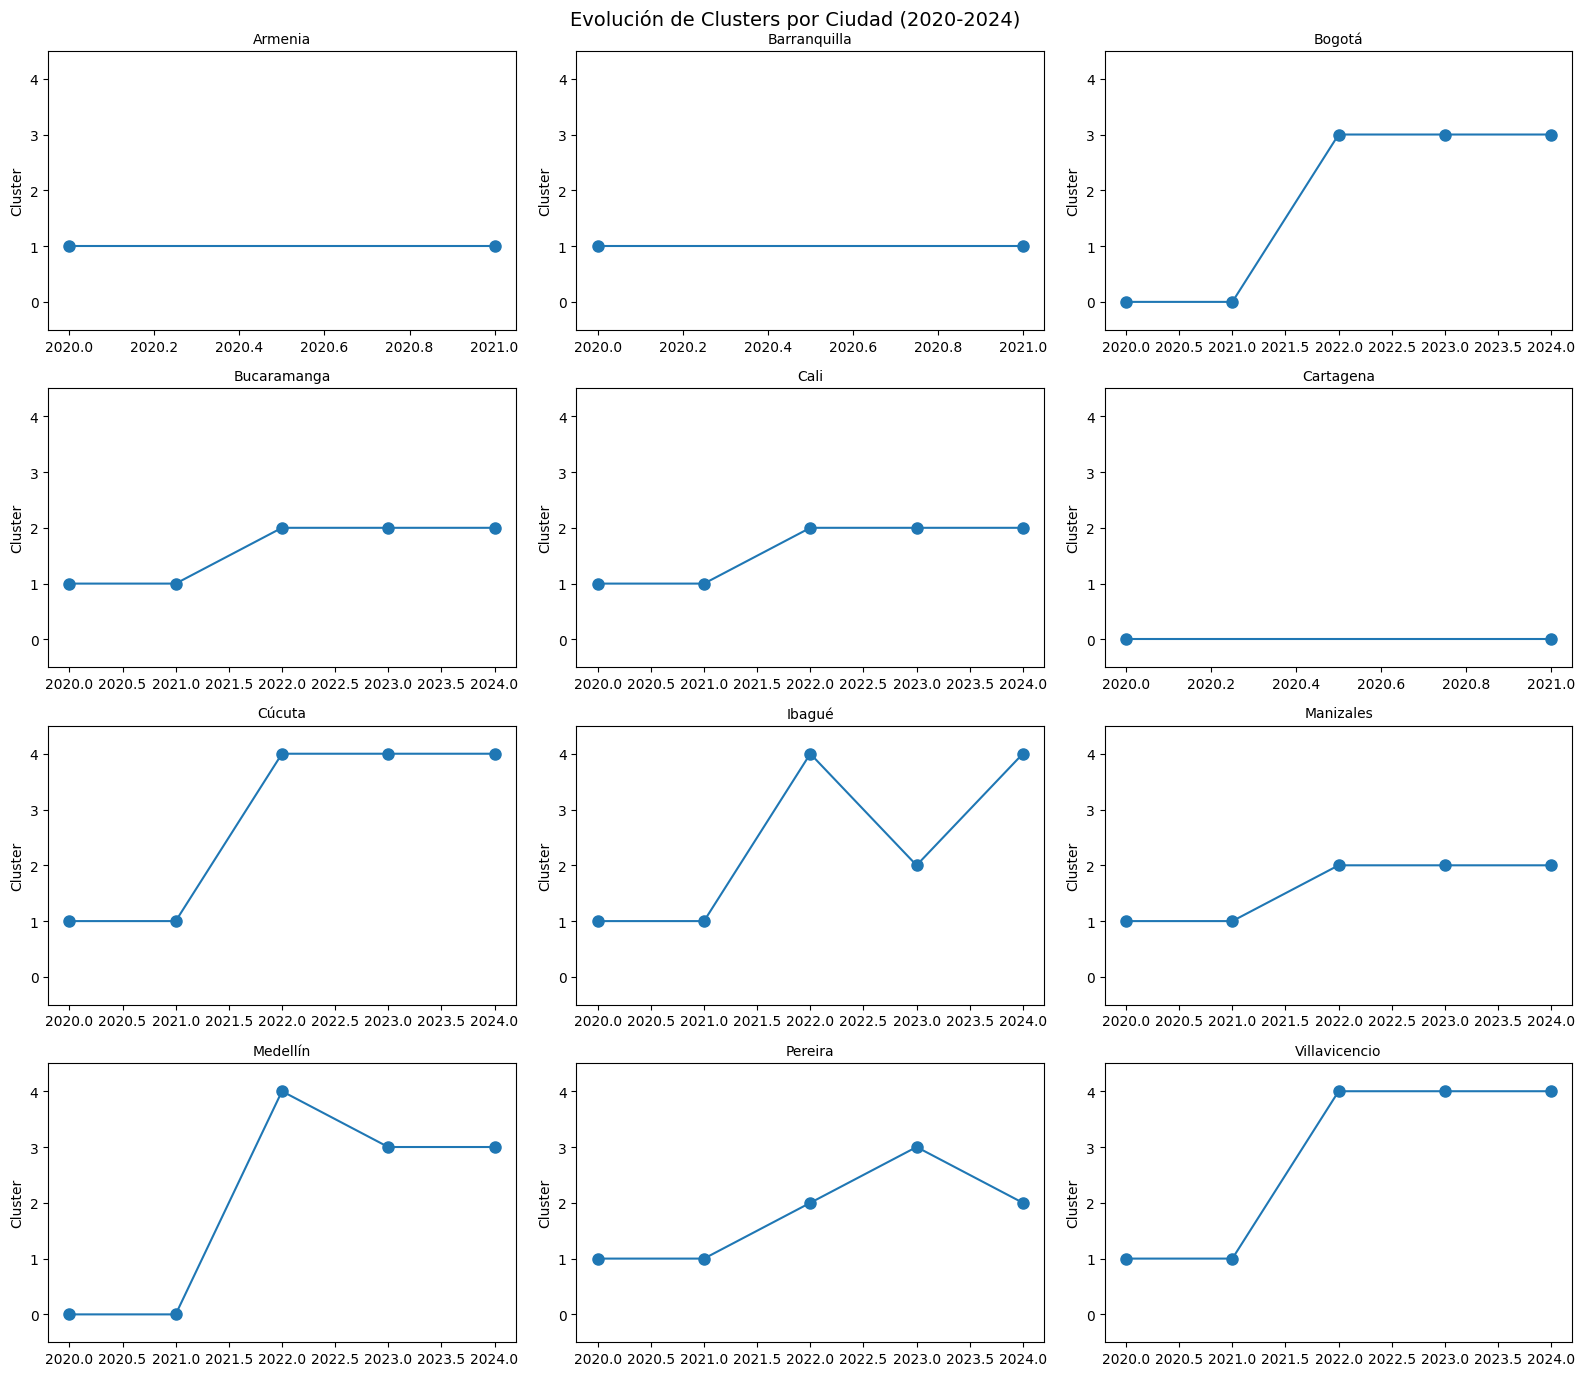

In [31]:
# Evolución temporal de clusters por ciudad
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
cities_sorted = sorted(df_cluster['city'].unique())
for i, city in enumerate(cities_sorted):
    ax = axes[i]
    subset = df_cluster[df_cluster['city'] == city].sort_values('year')
    ax.plot(subset['year'], subset['cluster'], 'o-', markersize=8)
    ax.set_title(city, fontsize=10)
    ax.set_ylim(-0.5, K_optimo - 0.5)
    ax.set_yticks(range(K_optimo))
    ax.set_ylabel('Cluster')

for j in range(len(cities_sorted), len(axes)):
    axes[j].axis('off')
plt.suptitle('Evolución de Clusters por Ciudad (2020-2024)', fontsize=14)
plt.tight_layout()
plt.savefig("models/clusters_evolucion.png", dpi=100, bbox_inches='tight')
plt.show()


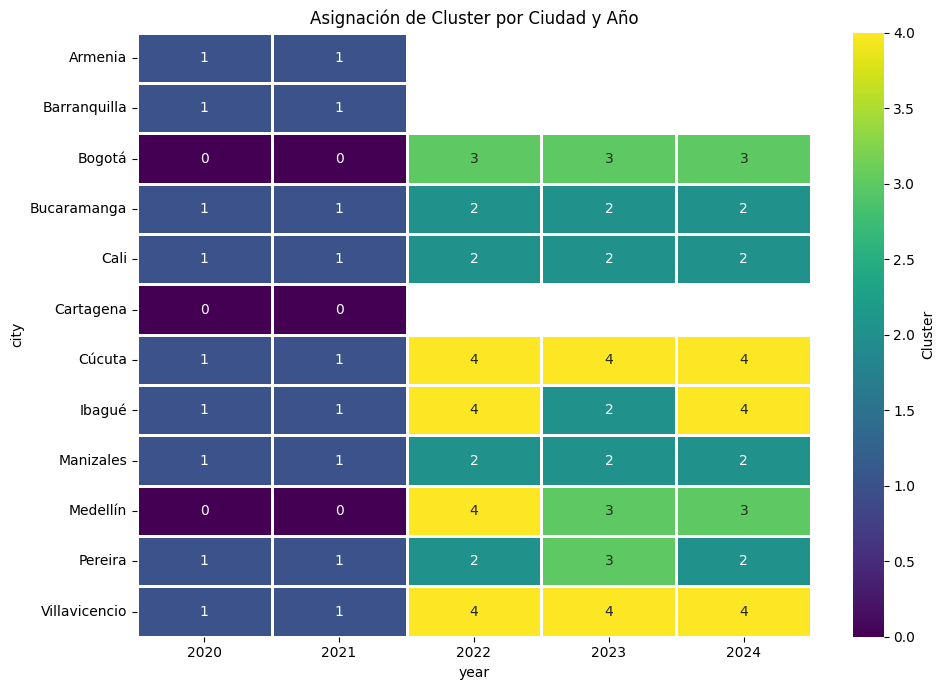

In [32]:
# Heatmap ciudad × año con cluster
heatmap_data = df_cluster.pivot_table(
    index='city', columns='year', values='cluster', aggfunc='first'
)
# Asegurar todas las combinaciones
for c in sorted(df_cluster['city'].unique()):
    for y in range(2020, 2025):
        if y not in heatmap_data.columns or pd.isna(heatmap_data.loc[c, y]):
            heatmap_data.loc[c, y] = np.nan

plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', cbar_kws={'label': 'Cluster'},
            linewidths=1, fmt='.0f')
plt.title('Asignación de Cluster por Ciudad y Año')
plt.tight_layout()
plt.savefig("models/clusters_heatmap.png", dpi=100, bbox_inches='tight')
plt.show()


## Sección 8: Validación con DBSCAN

In [33]:
# DBSCAN como contraste
for eps in [0.5, 0.8, 1.0]:
    db = DBSCAN(eps=eps, min_samples=3)
    labels = db.fit_predict(X_cluster)
    n_clusters_db = len(set(labels) - {-1})
    n_noise = list(labels).count(-1)
    print(f"eps={eps}: clusters={n_clusters_db}, ruido={n_noise} pts")
    noise_cities = df_cluster['city'][labels == -1].unique()
    if len(noise_cities) > 0:
        print(f"  Ciudades marcadas como ruido: {list(noise_cities)}")


eps=0.5: clusters=6, ruido=22 pts
  Ciudades marcadas como ruido: ['Bogotá', 'Cartagena', 'Cúcuta', 'Ibagué', 'Manizales', 'Medellín', 'Pereira', 'Villavicencio']
eps=0.8: clusters=4, ruido=8 pts
  Ciudades marcadas como ruido: ['Bogotá', 'Cartagena', 'Medellín', 'Pereira']
eps=1.0: clusters=3, ruido=0 pts


In [34]:
# Mejor configuración DBSCAN
db_final = DBSCAN(eps=0.8, min_samples=3)
df_cluster['dbscan_label'] = db_final.fit_predict(X_cluster)

print("Comparación DBSCAN vs KMeans:")
comparison = df_cluster.groupby('cluster')['dbscan_label'].apply(lambda x: x.value_counts().to_dict())
print(comparison.to_string())


Comparación DBSCAN vs KMeans:
cluster    
0         2     4.0
         -1     2.0
          1     NaN
          0     NaN
          3     NaN
1         2     NaN
         -1     NaN
          1    15.0
          0     3.0
          3     NaN
2         2     NaN
         -1     NaN
          1     NaN
          0     NaN
          3    12.0
3         2     NaN
         -1     6.0
          1     NaN
          0     NaN
          3     NaN
4         2     NaN
         -1     NaN
          1     NaN
          0     NaN
          3     9.0


## Sección 9: Análisis PCA

In [35]:
# PCA 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

print(f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"Varianza total: {pca.explained_variance_ratio_.sum():.2%}")

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=cluster_vars
).round(3)
print(f"\nLoadings (contribución de variables a cada PC):")
print(loadings.to_string())


Varianza explicada: PC1=70.18%, PC2=27.05%
Varianza total: 97.23%

Loadings (contribución de variables a cada PC):
                       PC1    PC2
IAH                  0.522  0.454
precio_m2            0.582  0.053
ratio_cuota_salario  0.578 -0.108
tasa_desempleo      -0.233  0.883


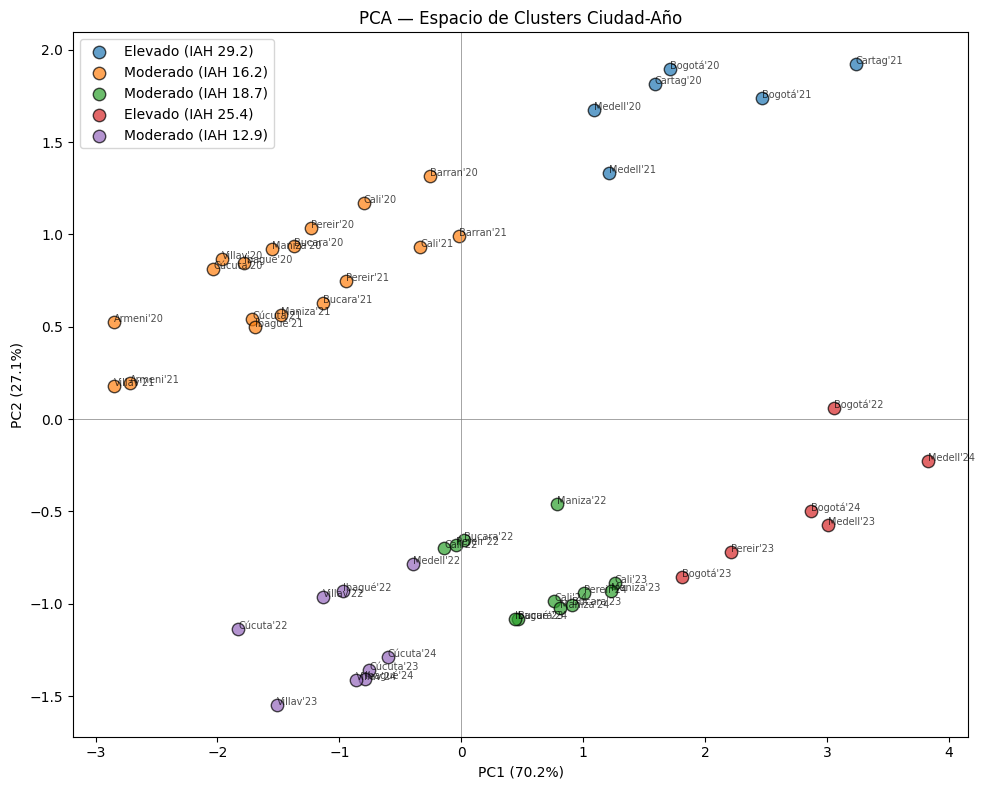

In [36]:
# Scatter PCA
df_cluster['PC1'] = X_pca[:, 0]
df_cluster['PC2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
for k in range(K_optimo):
    subset = df_cluster[df_cluster['cluster'] == k]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=cluster_names[k], s=80, alpha=0.7, edgecolors='k')
    for _, row in subset.iterrows():
        plt.annotate(f"{row['city'][:6]}'{str(row['year'])[-2:]}",
                     (row['PC1'], row['PC2']), fontsize=7, alpha=0.7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA — Espacio de Clusters Ciudad-Año')
plt.legend()
plt.axhline(y=0, color='gray', lw=0.5)
plt.axvline(x=0, color='gray', lw=0.5)
plt.tight_layout()
plt.savefig("models/pca_clusters.png", dpi=100, bbox_inches='tight')
plt.show()


## Sección 10: Exportación del Modelo de Clustering

In [37]:
# Guardar modelos de clustering
joblib.dump(kmeans, 'models/kmeans_segmentacion.pkl')
joblib.dump(scaler_cluster, 'models/scaler_cluster.pkl')
print("✅ models/kmeans_segmentacion.pkl guardado")
print("✅ models/scaler_cluster.pkl guardado")

# Exportar CSV de clusters
df_cluster.to_csv('data/processed/ciudades_clusters.csv', index=False)
print("✅ data/processed/ciudades_clusters.csv guardado")

# Exportar perfiles de clusters
perfiles.to_csv('data/processed/perfiles_clusters.csv')
print("✅ data/processed/perfiles_clusters.csv guardado")


✅ models/kmeans_segmentacion.pkl guardado
✅ models/scaler_cluster.pkl guardado
✅ data/processed/ciudades_clusters.csv guardado
✅ data/processed/perfiles_clusters.csv guardado


## Sección 11: Resumen Comparativo de Modelos

In [38]:
# Tabla comparativa
print("=" * 70)
print("COMPARATIVA FINAL: Ridge vs Random Forest")
print("=" * 70)
print(f"{'Métrica':<28} {'Ridge':>14} {'RF Opt':>14}")
print("-" * 56)
print(f"{'R²':<28} {r2_ridge:>14.4f} {r2_opt:>14.4f}")
print(f"{'MAE':<28} {mae_ridge:>14,.0f} {mae_opt:>14,.0f}")
print(f"{'RMSE':<28} {rmse_ridge:>14,.0f} {rmse_opt:>14,.0f}")
print(f"{'RMSE relativo (%)':<28} {rmse_rel_ridge:>14.2f} {rmse_rel_opt:>14.2f}")

# Selección de modelo ganador
print(f"\n{'='*70}")
if r2_opt > r2_ridge:
    print(f"✅ MODELO GANADOR: Random Forest (R²={r2_opt:.4f} vs Ridge {r2_ridge:.4f})")
else:
    print(f"✅ MODELO GANADOR: Ridge (más simple, R² competitivo)")


COMPARATIVA FINAL: Ridge vs Random Forest
Métrica                               Ridge         RF Opt
--------------------------------------------------------
R²                                   0.5382         0.6348
MAE                             204,253,848    168,048,700
RMSE                            320,466,412    284,996,129
RMSE relativo (%)                     76.30          67.86

✅ MODELO GANADOR: Random Forest (R²=0.6348 vs Ridge 0.5382)


In [39]:
# Criterios de éxito Fase 1
print("\n" + "=" * 60)
print("CRITERIOS DE ÉXITO — Fase 1 vs Fase 4")
print("=" * 60)
print(f"{'Criterio':<30} {'Umbral':>10} {'Obtenido':>10} {'Estado':>10}")
print("-" * 60)

criterios = {
    'R² en test': (0.75, r2_opt),
    'RMSE relativo < 15%': (15, rmse_rel_opt, True),
    'Coef. silueta ≥ 0.45': (0.45, silueta_final),
    'Clusters ≥ 3': (3, K_optimo)
}
for name, vals in criterios.items():
    if name == 'RMSE relativo < 15%':
        umbral, valor = 15, rmse_rel_opt
        cumple = valor < umbral
        print(f"{name:<30} {umbral:>10} {valor:>10.2f} {'✅' if cumple else '❌':>10}")
    elif name == 'Clusters ≥ 3':
        umbral, valor = 3, K_optimo
        cumple = valor >= umbral
        print(f"{name:<30} {umbral:>10} {valor:>10} {'✅' if cumple else '❌':>10}")
    else:
        umbral, valor = vals
        cumple = valor >= umbral
        print(f"{name:<30} {umbral:>10.2f} {valor:>10.4f} {'✅' if cumple else '❌':>10}")



CRITERIOS DE ÉXITO — Fase 1 vs Fase 4
Criterio                           Umbral   Obtenido     Estado
------------------------------------------------------------
R² en test                           0.75     0.6348          ❌
RMSE relativo < 15%                    15      67.86          ❌
Coef. silueta ≥ 0.45                 0.45     0.4874          ✅
Clusters ≥ 3                            3          5          ✅


In [40]:
# Decisión justificada
print("\n" + "=" * 60)
print("DECISIÓN DEL MODELO PARA PRODUCCIÓN")
print("=" * 60)

if r2_opt >= 0.75 and rmse_rel_opt < 15:
    decision = (
        f"Se selecciona Random Forest con parámetros {grid_search.best_params_} "
        f"para producción. R² en test de {r2_opt:.4f} y RMSE relativo de "
        f"{rmse_rel_opt:.2f}% cumplen los criterios de Fase 1."
    )
elif r2_opt >= 0.75:
    decision = (
        f"Random Forest seleccionado (R²={r2_opt:.4f}), pero RMSE relativo "
        f"({rmse_rel_opt:.2f}%) supera el umbral del 15%. Requiere revisión en Fase 5."
    )
else:
    decision = (
        f"Ningún modelo cumple R² ≥ 0.75. RF={r2_opt:.4f}, Ridge={r2_ridge:.4f}. "
        f"Documentar en Fase 5 las limitaciones y considerar ingeniería de features adicional."
    )
print(decision)
print(f"\nHiperparámetros finales: {grid_search.best_params_}")
print(f"Número de clusters: {K_optimo} (silueta={silueta_final:.4f})")



DECISIÓN DEL MODELO PARA PRODUCCIÓN
Ningún modelo cumple R² ≥ 0.75. RF=0.6348, Ridge=0.5382. Documentar en Fase 5 las limitaciones y considerar ingeniería de features adicional.

Hiperparámetros finales: {'regressor__max_depth': 20, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Número de clusters: 5 (silueta=0.4874)


## Sección 12: Preparación para GitHub

In [41]:
# Verificación final de entregables
import os
files = [
    'models/modelo_random_forest.pkl',
    'models/kmeans_segmentacion.pkl',
    'models/scaler_cluster.pkl',
    'models/features_order.json',
    'data/processed/ciudades_clusters.csv',
    'data/processed/perfiles_clusters.csv'
]
print("Verificación de entregables:")
all_ok = True
for f in files:
    exists = os.path.exists(f)
    size = os.path.getsize(f) if exists else 0
    status = '✅' if exists else '❌'
    print(f"  {status} {f} ({size:,} bytes)")
    if not exists:
        all_ok = False
print(f"\n{'✅ TODOS LOS ENTREGABLES OK' if all_ok else '❌ FALTAN ARCHIVOS'}")


Verificación de entregables:
  ✅ models/modelo_random_forest.pkl (448,622,538 bytes)
  ✅ models/kmeans_segmentacion.pkl (1,091 bytes)
  ✅ models/scaler_cluster.pkl (1,015 bytes)
  ✅ models/features_order.json (159 bytes)
  ✅ data/processed/ciudades_clusters.csv (7,633 bytes)
  ✅ data/processed/perfiles_clusters.csv (228 bytes)

✅ TODOS LOS ENTREGABLES OK


In [42]:
summary = f'''
========================================
  FASE 4 - MODELADO COMPLETADA
========================================
  Dataset:    {df.shape[0]:,} x {df.shape[1]}
  Modelo:     Random Forest (R2={r2_opt:.4f})
  Clusters:   K={K_optimo} (silueta={silueta_final:.4f})
  Criterios:  {"OK" if r2_opt >= 0.75 else "REVISAR"}
========================================
'''
print(summary)



  FASE 4 - MODELADO COMPLETADA
  Dataset:    282,660 x 26
  Modelo:     Random Forest (R2=0.6348)
  Clusters:   K=5 (silueta=0.4874)
  Criterios:  REVISAR

